# Детекция ботов по событиям куки

**Итоговый результат.** P@R0.7 = **0.877**

**КЛЮЧЕВЫЕ ИДЕИ**
1. **Убрать утечку :** 17% событий train записаны уже после окна наблюдения, в том числе все показы
   капчи - это фактически подсказка ответа. В test таких событий нет, выбрасываем их и из train (раздел 2)
2. **Поведение :** Положение курсора в динамике оказалось ключевым признаком. Боты действуют быстрее и как бы ровнее людей, листают выдачу глубже, а их курсор кучкуется и
   иногда упирается ровно в край экрана (разделы 3–4) (Это было проверено эмпирически)
3. **Бот-фермы.** Боты разных дней ходят по одним и тем же объявлениям, поэтому «репутация» объявления
   по прошлым дням очень сильный признак. (раздел 6)
4. **Модель** - среднее LightGBM и CatBoost. **Проверка** только по времени: учимся на ранних днях и
   проверяемся на более поздних как в настоящем test'е (разделы 5, 7).

**Запуск** Python 3.11.4, pip install -r requirements.txt, затем Run All. Нужны только папка
`data/` и выданный `metric.py` Сиды зафиксированы

**Разделы:** 1. Данные  2. Ловушки и очистка  3. Чем боты отличаются от людей  4. Признаки
5. Валидация  6. Подсказки из разметки  7. От baseline к итоговой модели  8. Абляции и цена утечки
9. Где модель ошибается  10. submission.csv  11. Выводы и ограничения

In [ ]:
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from catboost import CatBoostClassifier
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from metric import precision_at_recall   # официальная метрика

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

DATA_DIR = Path("data")
SEEDS = (0, 1, 2, 3, 4)    # все модели усредняются по этим сидам
T0 = time.time()

HUMAN, BOT = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": "#b5b4ad",
    "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "text.color": "#0b0b0b", "axes.grid": True, "grid.color": "#e8e7e2", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

## 1. Данные


Первый вопрос: как train и test разнесены во времени? От этого зависит, как проверять модель

In [ ]:
DATES = ["cookie_created_at", "window_start_ts", "window_end_ts"]
train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=DATES)
test = pd.read_csv(DATA_DIR / "test.csv", parse_dates=DATES)
events = pd.read_csv(DATA_DIR / "events.csv.gz", parse_dates=["event_ts"])
meta = pd.concat([train.drop(columns="target"), test], ignore_index=True)   # все куки без таргета
label = train.set_index("cookie_id")["target"]
y = train.target.to_numpy()

print("train", train.shape, "| test", test.shape, "| events", events.shape, "| доля ботов в train:", round(y.mean(), 4))
parts = pd.concat([train.assign(part="train"), test.assign(part="test")])
print("пересечение кук train/test:", len(set(train.cookie_id) & set(test.cookie_id)),
      "| длины окон:", sorted((parts.window_end_ts - parts.window_start_ts).unique()))
print("доля ботов по дням train: от", train.groupby("window_start_ts").target.mean().min().round(3),
      "до", train.groupby("window_start_ts").target.mean().max().round(3))
parts.groupby("part").window_start_ts.agg(["min", "max", "nunique"])

train (11091, 5) | test (4909, 4) | events (328905, 14) | доля ботов в train: 0.0811
пересечение кук train/test: 0 | длины окон: [Timedelta('1 days 00:00:00')]
доля ботов по дням train: от 0.063 до 0.093


,min,max,nunique
part,,,
test,2026-04-20,2026-04-26,7
train,2026-04-06,2026-04-19,14


 Test (20–26 апреля) целиком лежит позже train (6–19 апреля), куки не пересекаются, доля
ботов по дням стабильна (6–9%)

**Решение** проверять модель так же, как она будет работать на test: учиться на прошлом и
предсказывать будущее. Случайное перемешивание кук дало бы завышенную оценку

## 2. Ловушки в данных и очистка

### 2.1 События после окна и капча

По условию признаки должны быть доступны **к концу окна наблюдения**

In [ ]:
e = events.merge(meta[["cookie_id", "window_start_ts", "window_end_ts"]], on="cookie_id")
e["pos"] = np.select([e.event_ts < e.window_start_ts, e.event_ts >= e.window_end_ts],
                     ["до окна", "после окна"], "в окне")
e["part"] = np.where(e.cookie_id.isin(train.cookie_id), "train", "test")
display(pd.crosstab(e.part, e.pos, normalize="index").round(3))

print("captcha_shown по позиции:", e[e.event_name == "captcha_shown"].groupby(["part", "pos"]).size().to_dict())
after = e.loc[e.pos == "после окна", "cookie_id"].unique()
print("кук train с событиями после окна:", round(train.cookie_id.isin(after).mean(), 3))
print("доля ботов | есть события после окна:",
      train.assign(has_after=train.cookie_id.isin(after)).groupby("has_after").target.mean().round(3).to_dict())

pos,в окне,после окна
part,,
test,1.00,0.00
train,0.83,0.17


captcha_shown по позиции: {('train', 'после окна'): 7928}
кук train с событиями после окна: 0.476
доля ботов | есть события после окна: {False: 0.036, True: 0.131}


В train 17% событий (почти у половины кук) записаны уже после окна, в test - ни одного.
Сам факт «будущих» событий выдает класс: среди таких кук 13% ботов против 4% у остальных. А капча
показывается только после окна, тк это реакция антибот системы на уже пойманного бота, то есть подсказка
ответа

**Решение** Оставляем только события внутри окна `[window_start_ts, window_end_ts)`. В разделе 8
видно насколько без этого завысилась бы оценка

### 2.2 Дубли, платформа, User Agent, пропуски

User-Agent говорит чем кука заходит на сайт.
Из строки берем тип клиента и ОС

In [ ]:
PLATFORM_MAP = {"desktop": "desktop", "web": "desktop", "android": "android", "ios": "ios", "iphone": "ios"}


def parse_user_agent(ua: str) -> dict:
    # тип клиента
    if ua.startswith("Avito/"):
        kind = "app"
    elif "HeadlessChrome" in ua:
        kind = "headless"
    elif ua.startswith("Mozilla/"):
        kind = "browser"
    else:
        kind = "http_lib"
    # ОС — чтобы сверить с платформой
    if "Android" in ua:
        os_ = "android"
    elif "iPhone" in ua or "iOS" in ua:
        os_ = "ios"
    elif re.search(r"Windows|Macintosh|X11|Linux", ua):
        os_ = "desktop"
    else:
        os_ = "unknown"
    return {"ua_kind": kind, "ua_os": os_}


dup = events.duplicated()
print(f"точных дублей строк: {dup.mean():.2%}; среди событий людей / ботов:",
      dup.groupby(events.cookie_id.map(label)).mean().round(4).tolist(),
      "| совпадают по (кука, время, тип), но различаются содержимым:",
      events.duplicated(["cookie_id", "event_ts", "eid"]).sum() - dup.sum())
print("написаний платформы:", events.platform.nunique(), sorted(events.platform.unique()),
      "| в среднем на куку:", events.groupby("cookie_id").platform.nunique().mean().round(2))

et_raw = events[~dup].merge(train[["cookie_id", "target"]], on="cookie_id")   # события train без дублей
first = et_raw.groupby("cookie_id").agg(ua=("user_agent", "first"), target=("target", "first"))
print("шаблонов UA:", events.user_agent.drop_duplicates().map(lambda s: re.sub(r"\d+(\.\d+)*", "N", s)).nunique(),
      "| доля ботов по типу клиента:",
      first.target.groupby(first.ua.map(lambda u: parse_user_agent(u)["ua_kind"])).mean().round(3).to_dict())

plat = events.platform.str.lower().map(PLATFORM_MAP)
print("pointer_x заполнен по платформам:", events.pointer_x.notna().groupby(plat).mean().round(2).to_dict())
with_item = et_raw[et_raw.item_id.notna()]
print("доля пропусков в событиях с объявлением (0 — люди, 1 — боты):",
      with_item[["item_category", "item_location", "seller_type"]].isna().groupby(with_item.target).mean().round(3).to_dict())

print("\nзаполненность полей по типу события:")
cols = ["item_id", "item_category", "item_location", "seller_type", "search_query", "pointer_x"]
events[cols].notna().groupby(events.event_name).mean().round(2)

точных дублей строк: 1.48%; среди событий людей / ботов: [0.0148, 0.0142] | совпадают по (кука, время, тип), но различаются содержимым: 407
написаний платформы: 11 ['ANDROID', 'Android', 'IOS', 'WEB', 'Web', 'android', 'desktop', 'iOS', 'ios', 'iphone', 'web'] | в среднем на куку: 3.31
шаблонов UA: 19 | доля ботов по типу клиента: {'app': 0.092, 'browser': 0.069, 'headless': 0.262, 'http_lib': 0.22}


pointer_x заполнен по платформам: {'android': 0.0, 'desktop': 0.58, 'ios': 0.0}
доля пропусков в событиях с объявлением (0 — люди, 1 — боты): {'item_category': {0: 0.06, 1: 0.059}, 'item_location': {0: 0.03, 1: 0.031}, 'seller_type': {0: 0.091, 1: 0.089}}

заполненность полей по типу события:


,item_id,item_category,item_location,seller_type,search_query,pointer_x
event_name,,,,,,
captcha_shown,0.0,0.00,0.00,0.00,0.0,0.27
contact_chat_open,1.0,0.94,0.97,0.92,0.0,0.31
contact_message_sent,1.0,0.94,0.97,0.91,0.0,0.32
contact_phone_show,1.0,0.94,0.97,0.91,0.0,0.32
favorite_add,1.0,0.94,0.97,0.91,0.0,0.35
item_view,1.0,0.94,0.97,0.91,0.0,0.33
login,0.0,0.00,0.00,0.00,0.0,0.35
photo_swipe,1.0,0.94,0.97,0.91,0.0,0.34
search_results_view,0.0,0.94,0.97,0.00,1.0,0.33


**Что нашли и что с этим делаем**
- **События после окна** (2.1) - 17% событий train и вся капча, в test их нет. Оставляем только события
  внутри окна.
- **Дубли** - 1.5% строк это точные копии, одинаково у ботов и людей, то есть шум логирования. Удаляем.
  Около 400 событий в одну секунду с разным содержимым (другое объявление или город) это разные
  действия, их оставляем.
- **Платформа** - три платформы записаны 11 способами вперемешку внутри одной куки. Приводим к
  `desktop / android / ios`. Число написаний как признак не берем, оно просто повторяет число событий.
- **User-Agent** - ~150 строк сводятся к 19 шаблонам, которые отличаются только версиями. Даже у
  HeadlessChrome и HTTP-библиотек ботов всего 22–26%, так что это не правило, а обычный признак: берем
  тип клиента и ОС (чтобы сверить с платформой), версии выкидываем.
- **Пропуски, где поле не имеет смысла** - у поиска нет объявления, у входа в аккаунт нет ни объявления,
  ни запроса, курсор пишется только на desktop. Такие пропуски подсказывают, по каким событиям считать
  признак. Курсор считаем только по desktop, иначе признак кодировал бы платформу.
- **Случайные пропуски** - внутри «своих» событий нет категории у ~6%, города у ~3%, типа продавца у ~9%,
  одинаково у обоих классов. Это шум: ни признаком, ни отдельной категорией их не делаем.

Если признак у куки не определен (например курсор у мобильной куки), бустинги работают с пропуском
сами. Для логистической регрессии подставляем медиану и флаг «было пусто». **Все решения собраны в одну
функцию очистки**. Заодно проверяем, что кука никогда не создана позже начала окна. Значит и ее возраст
можно честно использовать как признак

In [ ]:
def clean_events(events, meta, window_filter=True):

    # window_filter=False нужен только для демонстрации утечки в разделе 8
    ev = events.drop_duplicates()
    ev = ev.merge(meta[["cookie_id", "window_start_ts", "window_end_ts"]], on="cookie_id", how="inner")
    if window_filter:
        ev = ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)]
    ev = ev.copy()
    ev["platform"] = ev["platform"].str.lower().map(PLATFORM_MAP)
    uas = ev["user_agent"].unique()
    ev = ev.join(pd.DataFrame([parse_user_agent(u) for u in uas], index=uas), on="user_agent")

    # eid вторичным ключом: события в одну секунду упорядочиваются детерминированно
    return ev.sort_values(["cookie_id", "event_ts", "eid"], kind="mergesort").reset_index(drop=True)


ev = clean_events(events, meta)
print(f"событий: {len(events)} -> {len(ev)}; captcha_shown осталось: {(ev.event_name == 'captcha_shown').sum()}")
print("платформы:", ev.platform.value_counts().to_dict())
print("cookie_created_at > window_start_ts:", (meta.cookie_created_at > meta.window_start_ts).sum())

событий: 328905 -> 283833; captcha_shown осталось: 0
платформы: {'desktop': 158898, 'android': 110556, 'ios': 14379}
cookie_created_at > window_start_ts: 0


## 3. Отличие ботов от людей

Прежде чем придумывать признаки, посмотрим, чем поведение ботов вообще отличается. Все ниже смотрим по
очищенным событиям train. Паузы длиннее 10 минут не берем, так как это уже перерыв, а не темп работы

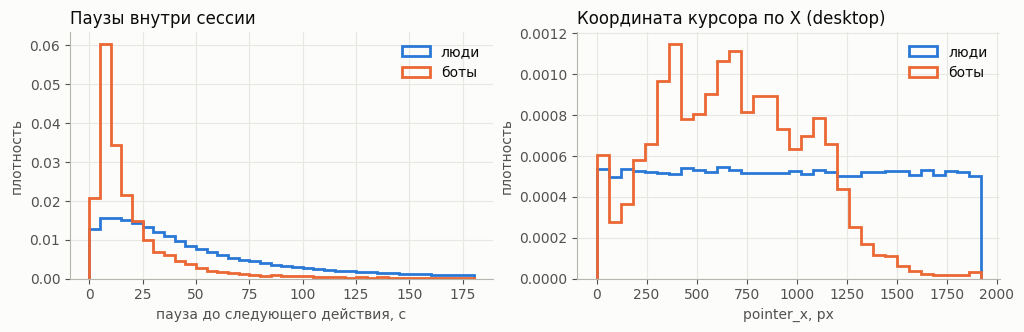

паузы, квартили 25/50/75%, с: люди [18.0, 38.0, 76.0] | боты [7.0, 12.0, 26.0]
std pointer_x по классам: {0: 554.0, 1: 363.0}
доля desktop-событий с курсором: {0: 0.662, 1: 0.33}
доля событий курсора ровно на краю экрана: {0: 0.0024, 1: 0.0778}
кук с >= 2 такими событиями: {0: 16, 1: 93}
доля ботов по возрасту куки, дней: {'0': 0.18, '1–3': 0.156, '4–14': 0.072, '15–90': 0.055, '> 90': 0.054}


In [ ]:
et = ev.merge(train[["cookie_id", "target"]], on="cookie_id")
gap = et.groupby("cookie_id").event_ts.diff().dt.total_seconds()
g = et.assign(gap=gap)[gap < 600]
dk = et[et.platform == "desktop"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.2))
for t, color, name in [(0, HUMAN, "люди"), (1, BOT, "боты")]:
    ax1.hist(g[g.target == t].gap, bins=np.arange(0, 181, 5), density=True, histtype="step", lw=2, color=color, label=name)
    ax2.hist(dk[dk.target == t].pointer_x.dropna(), bins=np.arange(0, 1921, 60), density=True,
             histtype="step", lw=2, color=color, label=name)
ax1.set_xlabel("пауза до следующего действия, с"); ax1.set_title("Паузы внутри сессии", loc="left")
ax2.set_xlabel("pointer_x, px"); ax2.set_title("Координата курсора по X (desktop)", loc="left")
for ax in (ax1, ax2):
    ax.set_ylabel("плотность"); ax.legend(frameon=False)
plt.show()

q = g.groupby("target").gap.quantile([0.25, 0.5, 0.75]).unstack()
print("паузы, квартили 25/50/75%, с: люди", q.loc[0].tolist(), "| боты", q.loc[1].tolist())
print("std pointer_x по классам:", dk.groupby("target").pointer_x.std().round(0).to_dict())
print("доля desktop-событий с курсором:", dk.pointer_x.notna().groupby(dk.target).mean().round(3).to_dict())
ptr = dk.dropna(subset=["pointer_x"])
on_edge = (ptr.pointer_x <= 0) | (ptr.pointer_x >= 1920) | (ptr.pointer_y <= 0) | (ptr.pointer_y >= 1080)
print("доля событий курсора ровно на краю экрана:", on_edge.groupby(ptr.target).mean().round(4).to_dict())
n_edge = on_edge.groupby(ptr.cookie_id).sum()
print("кук с >= 2 такими событиями:", (n_edge >= 2).groupby(ptr.groupby("cookie_id").target.first()).sum().to_dict())

age_days = (train.window_start_ts - train.cookie_created_at).dt.days
age_bin = pd.cut(age_days, [-1, 0, 3, 14, 90, 500], labels=["0", "1–3", "4–14", "15–90", "> 90"])
print("доля ботов по возрасту куки, дней:", train.groupby(age_bin, observed=True).target.mean().round(3).to_dict())

**Ритм.** Бот обычно делает следующее действие через 7–26 секунд, человек - через
  18–76 сек  и у людей длинный хвост долгих раздумий.
 **Курсор (только для декстопа).** У людей он равномерно распределен по всей ширине экрана, у ботов кучкуется
  в левой и центральной части и едва ли заходит правее 1250. У ботов координата записана лишь в
  трети desktop событий, а у людей - в двух третях
 **Края экрана.** Курсор бота разбросан вокруг своей «центральной точки» (внутри куки 200 px против
  550 у людей), а все что выходит за экран, записывается ровно как граница: x = 0, y = 0 или
  y = 1080. У людей на самую границу попадает 0.2% точек, у ботов — 8%; две такие точки есть у 93
  ботов и всего у 16 людей.
 **Возраст куки** Среди кук младше 3 дней ботов 16–18%, среди более старых — 5–7

**Вывод** Паузы, положение и разброс курсора, отдельно точки ровно на краю экрана и возраст куки -
основа признаков

## 4 Признаки

Все признаки считаются только по событиям внутри окна и сгруппированы по смыслу, чтобы потом проверить
вклад групп (раздел 8). **Сессия** — серия действий без перерывов дольше 10 минут.

- activity - число событий и сессий, событий в минуту, время первого события, доля ночных событий.
  Боты активнее и чаще работают ночью.
- rhythm - квантили и разброс пауз, доли очень коротких, коротких, средних и длинных пауз, сколько
  кука задерживается на объявлении, выдаче и фото. Темп - главный поведенческий сигнал.
- event_mix - доли 9 типов действий, число разных типов, доля повторов подряд. Люди чаще листают фото,
  добавляют в избранное и входят в аккаунт.
- content - сколько разных категорий и городов и насколько равномерно, повторы объявлений и запросов,
  глубина листания выдачи, доля объявлений от компаний. Боты обходят больше городов и листают глубже.
- pointer - доля событий с курсором, положение, разброс и шаг курсора, число и доля точек ровно на
  краю экрана (раздел 3).
- device платформа, тип клиента из UA, число разных UA, расхождение ОС из UA и платформы.
- popularity - насколько популярны объявления куки среди всех кук за последние 7 дней: боты
  концентрируются на одних и тех же объявлениях.
- cookie - возраст куки на начало окна, боты чаще сидят на свежих куках.

Сознательно **не** использую: число дублей и написаний платформы, флаги случайных пропусков, сырую
строку и версии UA (все это шум, раздел 2), день недели (в test другие даты).

In [ ]:
ACTIVE_GAP_S = 600   # пауза дольше 10 минут это перерыв между сессиями

EVENT_TYPES = ["search_results_view", "item_view", "photo_swipe", "seller_page_view", "favorite_add",
               "contact_phone_show", "contact_chat_open", "contact_message_sent", "login"]
ITEM_EVENTS = [e for e in EVENT_TYPES if e not in ("search_results_view", "login")]
PLATFORMS = ["desktop", "android", "ios"]
UA_KINDS = ["browser", "app", "headless", "http_lib"]


def _shares(mask, by):
    return mask.astype(float).groupby(by).mean()


def _dist_stats(ev, col, prefix):
    # число уникальных значений, энтропия и доля самого частого (Nan'ы не считается значением)
    cnt = ev.dropna(subset=[col]).groupby(["cookie_id", col]).size()
    p = cnt / cnt.groupby(level=0).transform("sum")
    return pd.DataFrame({
        f"{prefix}_nunique": cnt.groupby(level=0).size(),
        f"{prefix}_entropy": -(p * np.log(p)).groupby(level=0).sum(),
        f"{prefix}_top_share": p.groupby(level=0).max(),
    })


def activity_features(ev):
    cid = ev["cookie_id"]
    sec = (ev["event_ts"] - ev["window_start_ts"]).dt.total_seconds()
    hour = ev["event_ts"].dt.hour
    gap = sec.groupby(cid).diff()
    f = pd.DataFrame({
        "n_events": cid.groupby(cid).size(),
        "first_event_h": sec.groupby(cid).min() / 3600,
        "span_h": (sec.groupby(cid).max() - sec.groupby(cid).min()) / 3600,
        "n_sessions": (gap >= ACTIVE_GAP_S).groupby(cid).sum() + 1,
        "active_min": gap.where(gap < ACTIVE_GAP_S).groupby(cid).sum() / 60,
        "night_share": _shares(hour < 6, cid),
        "hours_nunique": hour.groupby(cid).nunique(),
    })
    f["events_per_session"] = f["n_events"] / f["n_sessions"]
    f["events_per_active_min"] = f["n_events"] / (f["active_min"] + 1)
    return f


def rhythm_features(ev):
    cid = ev["cookie_id"]
    gap = ev["event_ts"].groupby(cid).diff().dt.total_seconds()
    active = gap < ACTIVE_GAP_S
    ga = gap.where(active)
    lg = np.log1p(ga)
    g = ga.groupby(cid)
    f = pd.DataFrame({
        "gap_mean": g.mean(), "gap_median": g.median(), "gap_std": g.std(),
        "gap_q10": g.quantile(0.1), "gap_q25": g.quantile(0.25),
        "gap_q75": g.quantile(0.75), "gap_q90": g.quantile(0.9),
        "loggap_mean": lg.groupby(cid).mean(), "loggap_std": lg.groupby(cid).std(),
    })
    f["gap_cv"] = f["gap_std"] / f["gap_mean"]
    n_active = active.groupby(cid).sum().replace(0, np.nan)
    for name, lo, hi in [("0_2", -1, 2), ("3_15", 2, 15), ("16_45", 15, 45), ("gt45", 45, ACTIVE_GAP_S)]:
        f[f"gap_share_{name}"] = ((ga > lo) & (ga <= hi)).groupby(cid).sum() / n_active
    # сколько времени кука «задерживается» после конкретного действия
    next_gap = -ev["event_ts"].groupby(cid).diff(-1).dt.total_seconds()
    for name in ["item_view", "search_results_view", "photo_swipe"]:
        m = (ev["event_name"] == name) & (next_gap < ACTIVE_GAP_S)
        f[f"dwell_{name}"] = next_gap[m].groupby(cid[m]).median()
    return f


def event_mix_features(ev):
    cid = ev["cookie_id"]
    f = pd.DataFrame({f"share_{e}": _shares(ev["event_name"] == e, cid) for e in EVENT_TYPES})
    f["event_types_nunique"] = ev.groupby("cookie_id")["event_name"].nunique()
    prev = ev["event_name"].groupby(cid).shift()
    has_prev = prev.notna()
    f["repeat_event_share"] = (ev["event_name"] == prev)[has_prev].groupby(cid[has_prev]).mean()
    return f

In [ ]:
def content_features(ev):
    items = ev[ev["event_name"].isin(ITEM_EVENTS)]
    item_cnt = items.groupby("cookie_id")["item_id"].agg(["size", "nunique"])
    search = ev[ev["event_name"] == "search_results_view"]
    sg = search.groupby("cookie_id")
    f = pd.concat([
        _dist_stats(ev, "item_category", "cat"),
        _dist_stats(ev, "item_location", "loc"),
        pd.DataFrame({
            "items_nunique": item_cnt["nunique"],
            "item_repeat_share": 1 - item_cnt["nunique"] / item_cnt["size"],
            "queries_nunique": sg["search_query"].nunique(),
            "query_repeat_share": 1 - sg["search_query"].nunique() / sg.size(),
            "page_mean": sg["search_page"].mean(),
            "page_max": sg["search_page"].max(),
            "page1_share": _shares(search["search_page"] == 1, search["cookie_id"]),
            "pro_seller_share": _shares(items["seller_type"] == "pro", items["cookie_id"]),
        }),
    ], axis=1)
    return f.reindex(ev["cookie_id"].unique())


def pointer_features(ev):
    # поле есть только на desktop
    desk = ev[ev["platform"] == "desktop"]
    ptr = desk.dropna(subset=["pointer_x"])
    pg = ptr.groupby("cookie_id")
    step = np.hypot(pg["pointer_x"].diff(), pg["pointer_y"].diff())


    # курсор бота - нормаль, обрезанная краями экрана: вылетевшие точки записаны ровно на границе (раздел 3)
    on_edge = ((ptr["pointer_x"] <= 0) | (ptr["pointer_x"] >= 1920)
               | (ptr["pointer_y"] <= 0) | (ptr["pointer_y"] >= 1080)).groupby(ptr["cookie_id"])
    return pd.DataFrame({
        "desktop_share": _shares(ev["platform"] == "desktop", ev["cookie_id"]),
        "pointer_share": _shares(desk["pointer_x"].notna(), desk["cookie_id"]),
        "ptr_x_mean": pg["pointer_x"].mean(), "ptr_y_mean": pg["pointer_y"].mean(),
        "ptr_x_std": pg["pointer_x"].std(), "ptr_y_std": pg["pointer_y"].std(),
        "ptr_x_max": pg["pointer_x"].max(), "ptr_x_q90": pg["pointer_x"].quantile(0.9),
        "ptr_y_q90": pg["pointer_y"].quantile(0.9),
        "ptr_step_median": step.groupby(ptr["cookie_id"]).median(),
        "ptr_edge_n": on_edge.sum(), "ptr_edge_share": on_edge.mean(),
    })


def device_features(ev):
    g = ev.groupby("cookie_id")
    mismatch = (ev["ua_os"] != ev["platform"]) & (ev["ua_os"] != "unknown")
    return pd.DataFrame({
        "platform": pd.Categorical(g["platform"].agg(lambda s: s.mode().iat[0]), categories=PLATFORMS),
        "ua_kind": pd.Categorical(g["ua_kind"].agg(lambda s: s.mode().iat[0]), categories=UA_KINDS),
        "ua_nunique": g["user_agent"].nunique(),
        "ua_os_mismatch_share": _shares(mismatch, ev["cookie_id"]),
    }, index=g.size().index)


def cookie_features(meta):
    m = meta.set_index("cookie_id")
    return pd.DataFrame({"cookie_age_days": (m["window_start_ts"] - m["cookie_created_at"]).dt.total_seconds() / 86400})

**Популярность объявлений** — единственный признак раздела, который смотрит на другие куки, поэтому
важно не заглянуть в будущее. Для куки с окном в день D считаем, сколько других кук смотрели те же
объявления в дни с D − 6 по D: окна начинаются в полночь и длятся сутки, так что к концу окна все эти
события уже произошли. Метки не используются, сама кука из подсчета исключена. Счетчик делим на объем
трафика за эти 7 дней. Иначе в первые дни train (короткая история) он был бы систематически меньше
чем в тесте

In [ ]:
def item_popularity_features(ev, window_days=7):
    pairs = (ev.loc[ev["item_id"].notna(), ["cookie_id", "item_id", "window_start_ts"]]
             .drop_duplicates(["cookie_id", "item_id"]))
    day = (pairs["window_start_ts"] - pairs["window_start_ts"].min()).dt.days.to_numpy()
    item_codes, _ = pd.factorize(pairs["item_id"])
    n_days = day.max() + 1

    # cnt[item, day] - сколько разных кук смотрели объявление в этот день. сумма по окну через cumsum
    cnt = np.zeros((item_codes.max() + 1, n_days), dtype=np.int32)
    np.add.at(cnt, (item_codes, day), 1)
    csum = np.concatenate([np.zeros((cnt.shape[0], 1), dtype=np.int64), cnt.cumsum(axis=1)], axis=1)
    lo = np.maximum(day - window_days + 1, 0)
    viewers = csum[item_codes, day + 1] - csum[item_codes, lo] - 1   # без самой куки



    pcum = np.r_[0, np.bincount(day, minlength=n_days).cumsum()]
    traffic = (pcum[day + 1] - pcum[lo]) / 1e4   # пар (кука, объявление) в окне, в десятках тысяч
    g = pd.Series(viewers / traffic, index=pairs.index).groupby(pairs["cookie_id"])
    return pd.DataFrame({"item_pop_mean": g.mean(), "item_pop_median": g.median(),
                         "item_pop_max": g.max(), "item_pop_q75": g.quantile(0.75)})


FEATURE_BUILDERS = {
    "activity": activity_features, "rhythm": rhythm_features, "event_mix": event_mix_features,
    "content": content_features, "pointer": pointer_features, "device": device_features,
    "popularity": item_popularity_features,
}


def build_features(ev, meta):
    parts = {name: fn(ev) for name, fn in FEATURE_BUILDERS.items()}
    parts["cookie"] = cookie_features(meta)
    groups = {name: list(df.columns) for name, df in parts.items()}
    X = pd.concat(parts.values(), axis=1).reindex(meta["cookie_id"])
    return X, groups


X_all, groups = build_features(ev, meta)
X = X_all.loc[train.cookie_id]          # индекс - cookie_id
X_test = X_all.loc[test.cookie_id]
print("признаков:", X.shape[1], "|", {k: len(v) for k, v in groups.items()})

признаков: 72 | {'activity': 9, 'rhythm': 17, 'event_mix': 11, 'content': 14, 'pointer': 12, 'device': 4, 'popularity': 4, 'cookie': 1}


## 5. Как честно измерять качество

**Схема.** Модель будет предсказывать дни которых не видела, поэтому и проверяем ее так же. Делим train
на три блока по времени. В каждом раунде проверки (**фолде**) модель учится только на днях до блока и
предсказывает сам блок. с каждым фолдом история растет. Итоговая модель потом учится на всех 14 днях
train и предсказывает test.

**Шум** В каждом блоке всего 190–230 ботов: один-два бота по ту или другую сторону порога сдвигают
P@R0.7 на несколько сотых, фолды расходятся на 0.03–0.05. Поэтому смотрим на среднее по трем фолдам и
на согласие фолдов, а не на третий знак. Близкие варианты сравниваем еще и по **P@R0.6–0.8** (метрике которую я решил взять в дополнение)
. Она усреднена по порогам полноты 0.6, 0.65, 0.7, 0.75 и 0.8. Меньше зависит от того, куда
упал отдельный бот

In [ ]:
VALID_BLOCKS = [("2026-04-10", "2026-04-13"), ("2026-04-13", "2026-04-16"), ("2026-04-16", "2026-04-20")]
ws = train["window_start_ts"]
FOLDS = [((ws < a).to_numpy(), ((ws >= a) & (ws < b)).to_numpy()) for a, b in VALID_BLOCKS]

day_span = lambda mask: f"{ws[mask].min():%d.%m} – {ws[mask].max():%d.%m}"
display(pd.DataFrame([{"фолд": i + 1, "учимся на днях": day_span(tr), "проверяем на днях": day_span(va),
                       "кук в проверке": va.sum(), "ботов в проверке": y[va].sum()}
                      for i, (tr, va) in enumerate(FOLDS)]).set_index("фолд"))

RESULTS = []   # строки итоговых таблиц экспериментов


def pr_band(y_true, score, recalls=(0.6, 0.65, 0.7, 0.75, 0.8)):
    return np.mean([precision_at_recall(y_true, score, r) for r in recalls])


def record(section, name, preds):
    scores = [precision_at_recall(y[va], p) for (_, va), p in zip(FOLDS, preds)]
    oof_y = np.concatenate([y[va] for _, va in FOLDS])
    oof_p = np.concatenate(preds)
    RESULTS.append({"раздел": section, "модель": name, "P@R0.7": np.mean(scores),
                    **{f"фолд {i + 1}": s for i, s in enumerate(scores)},
                    "P@R0.6–0.8": np.mean([pr_band(y[va], p) for (_, va), p in zip(FOLDS, preds)]),
                    # по объединенным OOF: калибровка между фолдами разная, это только диагностика
                    "ROC-AUC": roc_auc_score(oof_y, oof_p), "PR-AUC": average_precision_score(oof_y, oof_p)})
    return preds


def results_table(section):
    df = pd.DataFrame(RESULTS)
    return df[df["раздел"] == section].drop(columns="раздел").set_index("модель").round(3)

,учимся на днях,проверяем на днях,кук в проверке,ботов в проверке
фолд,,,,
1,06.04 – 09.04,10.04 – 12.04,2625,228
2,06.04 – 12.04,13.04 – 15.04,2470,188
3,06.04 – 15.04,16.04 – 19.04,2691,220


## 6. Подсказки из разметки: репутация объявлений и LLR-признаки по событиям

Признаки раздела 4 я считал без меток. Но метки train позволяют вытащить больше, например узнать, какие
объявления «любят» боты. Это кодирование по таргету, и здесь проще всего обмануть самого себя: если
посчитать «долю ботов среди кук, смотревших объявление» с учетом самой куки, признак будет содержать ее
собственный ответ. На проверке все будет прекрасно, а на test, где ответов нет, качество упадет.

Поэтому я держался одного правила: **кука никогда не видит меток своего дня**. Для кук обучающей части
признак считается по меткам всех остальных дней (out-of-fold по дням), для кук из проверки и test - по
всей обучающей истории, то есть только по прошлому. Внутри каждого фолда все пересчитывается заново по
его обучающей части. Эту схему я вынес в общий класс DayOOFEncoder, от которого наследуются оба
кодировщика ниже.

### 6.1 Репутация объявлений

Разбирая данные, я заметил, что боты разных дней ходят по одному и тому же набору объявлений. Похоже на
фермы, которые меняют куки, но парсят одни и те же листинги. Поэтому для каждого объявления я считаю
долю ботов среди смотревших его кук и переношу это на куку: средняя и максимальная «ботовость» ее
объявлений и доля объявлений, где боты уже встречались.

Редкие объявления я сглаживаю: подмешиваю двух «виртуальных» зрителей с общей долей ботов. Тогда
3 бота из 4 зрителей дают (3 + 2·0.08) / (4 + 2) = 0.53, а не 0.75. Объявление, которого в истории нет,
получает просто общую долю ботов.

**Не устаревает ли репутация?** В test между последними известными метками и прогнозом проходит 1–7
дней, поэтому я проверил, как быстро сигнал «протухает»: посчитал репутацию только по меткам 6–9 апреля
и посмотрел, насколько хорошо она отделяет ботов в каждый следующий день (ROC-AUC: 0.5 - никак,
1 - идеально).

In [ ]:
class DayOOFEncoder:
    """Общая схема кодирования по таргету: _fit(ids, y) -> статистики, _encode(статистики, ids) -> признаки."""

    def fit_transform_oof(self, cookie_ids, y, days):
        # обучающие строки: для каждого дня — по меткам всех остальных дней
        parts = []
        for d in np.unique(days):
            hold = days == d
            parts.append(self._encode(self._fit(cookie_ids[~hold], y[~hold]), cookie_ids[hold]))
        return pd.concat(parts).reindex(cookie_ids)

    def transform(self, train_ids, y, cookie_ids):
        # новые куки: по всей размеченной истории
        return self._encode(self._fit(train_ids, y), cookie_ids)


PRIOR_WEIGHT = 2.0


def item_pairs(ev):
    return ev.loc[ev["item_id"].notna(), ["cookie_id", "item_id"]].drop_duplicates()


class ItemBotEncoder(DayOOFEncoder):
    def __init__(self, pairs):
        self.pairs = pairs            # уникальные пары (cookie_id, item_id)

    def _fit(self, cookie_ids, y):
        label = pd.Series(y, index=cookie_ids)
        p = self.pairs[self.pairs["cookie_id"].isin(label.index)]
        t = p["cookie_id"].map(label)
        stats = t.groupby(p["item_id"]).agg(["sum", "size"]).rename(columns={"sum": "bots", "size": "viewers"})
        return stats, float(np.mean(y))

    def _encode(self, fitted, cookie_ids):
        stats, prior = fitted
        q = self.pairs[self.pairs["cookie_id"].isin(cookie_ids)].join(stats, on="item_id")
        q = q.fillna({"bots": 0, "viewers": 0})
        rate = (q["bots"] + PRIOR_WEIGHT * prior) / (q["viewers"] + PRIOR_WEIGHT)
        g = rate.groupby(q["cookie_id"])
        return pd.DataFrame({
            "item_bot_rate_mean": g.mean(),
            "item_bot_rate_max": g.max(),
            "item_bot_seen_share": (q["bots"] > 0).groupby(q["cookie_id"]).mean(),
        }).reindex(cookie_ids)


item_encoder = ItemBotEncoder(item_pairs(ev))
day_of = train.set_index("cookie_id")["window_start_ts"]

# устаревание: репутация по меткам 6–9 апреля против каждого следующего дня
hist = day_of[day_of < "2026-04-10"].index.to_numpy()
rows = []
for d in pd.date_range("2026-04-10", "2026-04-19"):
    ids = day_of[day_of == d].index.to_numpy()
    f = item_encoder.transform(hist, label.loc[hist].to_numpy(), ids)["item_bot_rate_mean"].dropna()
    rows.append({"день": d.date(), "задержка, дней": (d - pd.Timestamp("2026-04-09")).days,
                 "AUC": round(roc_auc_score(label.loc[f.index], f), 3)})
pd.DataFrame(rows).set_index("день").T

день,2026-04-10,2026-04-11,2026-04-12,2026-04-13,2026-04-14,2026-04-15,2026-04-16,2026-04-17,2026-04-18,2026-04-19
"задержка, дней",1.000,2.000,3.000,4.000,5.000,6.000,7.000,8.000,9.000,10.000
AUC,0.776,0.811,0.752,0.771,0.814,0.771,0.792,0.732,0.779,0.795


ROC-AUC держится на 0.73–0.81 и через день, и через десять дней. Сигнал не затухает, так
что историю train можно смело применять к test

### 6.2 LLR-признаки по отдельным событиям

Признаки раздела 4 описывают куку сводками (медиана паузы, разброс курсора), а при 3–10 событиях такие
сводки получаются шумными. Поэтому я добавил второй способ: оценивать каждое событие по отдельности. Для
каждого значения атрибута события (пауза до него, где был курсор, какая страница выдачи, какое действие
шло перед ним, час и т.д.) я по обучающим кукам смотрю, насколько чаще оно встречается у ботов, чем у
людей:

`LLR = log(доля среди событий ботов / доля среди событий людей)`

Это логарифм отношения правдоподобия (log-likelihood ratio). Положительное значение сдвигает оценку в
сторону бота, отрицательное - в сторону человека, около нуля - значение ни о чем не говорит. Дальше я
суммирую LLR по всем событиям куки отдельно для каждого атрибута и получаю признаки `llr_*`. По сути это
наивный Байес, только его суммы идут не в итоговый ответ, а признаками в бустинг. Сумма учитывает и силу,
и количество: одна быстрая пауза почти ничего не значит, двадцать - уже серьезно. Складывать LLR честно
только для независимых событий, а события одной куки зависимы, поэтому сумма - не вероятность, а просто
признак, и калибровать ее я не пытался. Считается она по той же защищенной схеме, что и репутация
объявлений.

Ниже несколько значений и их вклад (LLR) по всему train, только для иллюстрации:

In [ ]:
LLR_ALPHA = 1.0     # сглаживание Лапласа: редкие значения не дают экстремальных LLR


def event_tokens(ev):
    """Длинная таблица (cookie_id, attr, tok): дискретизированные атрибуты каждого события."""
    cid = ev["cookie_id"]
    gap = ev["event_ts"].groupby(cid).diff().dt.total_seconds()
    next_gap = -ev["event_ts"].groupby(cid).diff(-1).dt.total_seconds()
    next_bin = np.floor(np.log1p(next_gap.where(next_gap < ACTIVE_GAP_S)) * 2)
    desk = ev["platform"] == "desktop"
    prev = ev["event_name"].groupby(cid).shift().fillna("START")
    attrs = {
        "gap": np.floor(np.log1p(gap.where(gap < ACTIVE_GAP_S)) * 3),       # лог-бины паузы до события
        "ptr_x": (ev["pointer_x"] // 96).where(desk),                        # 20 полос по X
        "ptr_y": (ev["pointer_y"] // 54).where(desk),                        # 20 полос по Y
        "ptr_cell": (ev["pointer_x"] // 240 * 10 + ev["pointer_y"] // 180).where(desk),   # сетка 8×6
        "ptr_missing": ev["pointer_x"].isna().where(desk),
        "page": ev["search_page"].clip(upper=20),
        "event": ev["event_name"],
        "transition": prev + ">" + ev["event_name"],
        "dwell": ev["event_name"] + ":" + next_bin.astype(str).where(next_bin.notna()),
        "hour": ev["event_ts"].dt.hour,
        "category": ev["item_category"],
        "location": ev["item_location"],
    }
    parts = []
    for name, tok in attrs.items():
        m = tok.notna()      # структурные пропуски (нет курсора, нет выдачи). Значит не событие для атрибута
        parts.append(pd.DataFrame({"cookie_id": cid[m].to_numpy(), "attr": name, "tok": tok[m].astype(str).to_numpy()}))
    return pd.concat(parts, ignore_index=True)


class EventLLREncoder(DayOOFEncoder):
    def __init__(self, tokens):
        self.tokens = tokens

    def _fit(self, cookie_ids, y):
        # для каждого значения атрибута: его доля среди событий ботов и среди событий людей
        label = pd.Series(y, index=cookie_ids)
        t = self.tokens[self.tokens["cookie_id"].isin(label.index)]
        cnt = t.groupby(["attr", "tok", t["cookie_id"].map(label)]).size().unstack(fill_value=0)
        n_values = cnt.groupby(level="attr")[0].transform("size")
        total = cnt.groupby(level="attr").transform("sum")
        p = pd.DataFrame({"p_bot": (cnt[1] + LLR_ALPHA) / (total[1] + LLR_ALPHA * n_values),
                          "p_human": (cnt[0] + LLR_ALPHA) / (total[0] + LLR_ALPHA * n_values)})
        p["llr"] = np.log(p["p_bot"] / p["p_human"])
        return p

    def _encode(self, fitted, cookie_ids):
        t = self.tokens[self.tokens["cookie_id"].isin(cookie_ids)].join(fitted["llr"], on=["attr", "tok"])
        s = t["llr"].fillna(0).groupby([t["cookie_id"], t["attr"]]).sum()     # незнакомое значение — 0
        return s.unstack().add_prefix("llr_").reindex(cookie_ids)


llr_encoder = EventLLREncoder(event_tokens(ev))

# иллюстрация: вклад нескольких понятных значений по всему train (в модели не используется)
EXAMPLES = {
    ("gap", "5.0"): "пауза до действия 5–6 с",
    ("gap", "11.0"): "пауза до действия 39–53 с",
    ("page", "12.0"): "12-я страница выдачи",
    ("page", "1.0"): "первая страница выдачи",
    ("hour", "3"): "действие в 3 часа ночи",
    ("event", "favorite_add"): "добавление в избранное",
    ("ptr_y", "20.0"): "курсор ровно на нижней границе (y = 1080)",
    ("ptr_x", "17.0"): "курсор у правого края (x 1632–1727)",
}
p = llr_encoder._fit(train.cookie_id.to_numpy(), y).loc[list(EXAMPLES)]
pd.DataFrame({"доля у ботов, %": 100 * p["p_bot"].to_numpy(), "доля у людей, %": 100 * p["p_human"].to_numpy(),
              "вклад": p["llr"].to_numpy()}, index=pd.Index(EXAMPLES.values(), name="значение")).round(2)

,"доля у ботов, %","доля у людей, %",вклад
значение,,,
пауза до действия 5–6 с,13.02,2.85,1.52
пауза до действия 39–53 с,5.73,12.39,-0.77
12-я страница выдачи,1.49,0.22,1.90
первая страница выдачи,24.96,41.41,-0.51
действие в 3 часа ночи,5.58,2.54,0.79
добавление в избранное,2.73,6.57,-0.88
курсор ровно на нижней границе (y = 1080),2.28,0.03,4.26
курсор у правого края (x 1632–1727),0.17,4.97,-3.37


Пауза 5–6 секунд - это 13% пауз у ботов и 3% у людей, поэтому каждое такое событие
добавляет +1.5 в сторону «бот». Первая страница выдачи, добавление в избранное, курсор у правого края
экрана говорят в пользу человека. Самое сильное значение - курсор ровно на нижней границе экрана (+4.3):
это тот же эффект краев, что и в разделе 3

## 7. От baseline к итоговой модели

Идем от простого к сложному, все модели проверяются на одних и тех же трех фолдах:
- **константа** — всем одинаковый score, тогда P@R0.7 равен доле ботов (нижняя граница), и **baseline из
  quickstart** — случайный лес на числе событий и числе объявлений;
- **логистическая регрессия** и **LightGBM** на поведенческих признаках. Ботов в train всего ~900,
  поэтому деревья маленькие и сильно регуляризованы, а extra_trees выбирает пороги разбиений случайно —
  это еще сильнее мешает подгонке под шум;
- к LightGBM по очереди добавляем **репутацию объявлений** и **LLR-признаки по событиям** (раздел 6);
- **CatBoost** — второй бустинг с другим устройством деревьев, на тех же признаках;
- **итог** — среднее вероятностей LightGBM и CatBoost: разные модели ошибаются по-разному, и среднее
  устойчивее каждой из них. Усредняем вероятности, а не ранги: среднее рангов дает одинаковые score
  разным кукам, а метрика может отметить группу одинаковых score только целиком.

Каждая модель усредняется по 5 сидам. Кодирования из раздела 6 зависят только от фолда, поэтому
считаются один раз; модели без них просто не получают эти колонки.

In [ ]:
LGBM_PARAMS = dict(objective="binary", learning_rate=0.03, n_estimators=1000, num_leaves=15,
                   min_child_samples=40, subsample=0.8, subsample_freq=1, colsample_bytree=0.7,
                   reg_lambda=5.0, extra_trees=True, verbose=-1)
CATBOOST_PARAMS = dict(iterations=800, learning_rate=0.05, depth=5, l2_leaf_reg=5, verbose=0,
                       allow_writing_files=False)


def categorical(X_):
    return [c for c in X_.columns if isinstance(X_[c].dtype, pd.CategoricalDtype)]


def constant(Xa, ya, Xb):
    return np.full(len(Xb), 0.5)


def quickstart_rf(Xa, ya, Xb):
    cols = ["n_events", "items_nunique"]
    m = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=-1)
    return m.fit(Xa[cols].fillna(0), ya).predict_proba(Xb[cols].fillna(0))[:, 1]


def logreg(Xa, ya, Xb):
    cat = categorical(Xa)
    num = [c for c in Xa.columns if c not in cat]
    pre = ColumnTransformer([
        ("num", make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler()), num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
    ])
    return make_pipeline(pre, LogisticRegression(C=0.1, max_iter=2000)).fit(Xa, ya).predict_proba(Xb)[:, 1]


def make_lgbm(**overrides):
    params = {**LGBM_PARAMS, **overrides}

    def fit_predict(Xa, ya, Xb):
        return np.mean([lgb.LGBMClassifier(**params, random_state=s).fit(Xa, ya).predict_proba(Xb)[:, 1]
                        for s in SEEDS], axis=0)
    return fit_predict


lgbm = make_lgbm()


def catboost(Xa, ya, Xb):
    cat = categorical(Xa)
    to_str = lambda X_: X_.assign(**{c: X_[c].astype(str) for c in cat})
    return np.mean([CatBoostClassifier(**CATBOOST_PARAMS, random_seed=s, cat_features=cat, thread_count=-1)
                    .fit(to_str(Xa), ya).predict_proba(to_str(Xb))[:, 1] for s in SEEDS], axis=0)


def add_encodings(Xa, ya, Xb):
    # признаки раздела 6 по меткам обучающей части: для Xa — out-of-fold по дням, для Xb — по всей истории
    ids_a, ids_b = Xa.index.to_numpy(), Xb.index.to_numpy()
    days_a = day_of.loc[ids_a].to_numpy()
    for enc in (item_encoder, llr_encoder):
        Xa = Xa.join(enc.fit_transform_oof(ids_a, ya, days_a))
        Xb = Xb.join(enc.transform(ids_a, ya, ids_b))
    return Xa, Xb


FOLD_DATA = [add_encodings(X[tr], y[tr], X[va]) for tr, va in FOLDS]   # (обучение, проверка) по фолдам
ENC_COLS = [c for c in FOLD_DATA[0][0].columns if c not in X.columns]
LLR_COLS = [c for c in ENC_COLS if c.startswith("llr_")]
ITEM_COLS = [c for c in ENC_COLS if c not in LLR_COLS]


def evaluate(section, name, model, drop=()):
    # model(X_train, y_train, X_valid) -> score; drop — колонки, которых модель не получает
    drop = list(drop)
    return record(section, name, [model(Xa.drop(columns=drop), y[tr], Xb.drop(columns=drop))
                                  for (tr, _), (Xa, Xb) in zip(FOLDS, FOLD_DATA)])

In [ ]:
t = time.time()
evaluate("main", "Константа", constant)
evaluate("main", "Baseline из quickstart: RandomForest на n_events + items_nunique", quickstart_rf)
evaluate("main", "Логистическая регрессия, поведенческие признаки", logreg, drop=ENC_COLS)
evaluate("main", "LightGBM, поведенческие признаки", lgbm, drop=ENC_COLS)
evaluate("main", "LightGBM + репутация объявлений", lgbm, drop=LLR_COLS)
p_lgbm = evaluate("main", "LightGBM + репутация + LLR по событиям", lgbm)
p_cat = evaluate("main", "CatBoost + репутация + LLR по событиям", catboost)
# итог = среднее двух моделей; предсказания по фолдам уже посчитаны, переобучать не нужно
p_final = record("main", "Итог: среднее LightGBM и CatBoost", [(a + b) / 2 for a, b in zip(p_lgbm, p_cat)])
print(f"({time.time() - t:.0f} с)")
results_table("main")

(190 с)


,P@R0.7,фолд 1,фолд 2,фолд 3,P@R0.6–0.8,ROC-AUC,PR-AUC
модель,,,,,,,
Константа,0.082,0.087,0.076,0.082,0.082,0.500,0.082
Baseline из quickstart: RandomForest на n_events + items_nunique,0.096,0.102,0.093,0.092,0.096,0.606,0.213
"Логистическая регрессия, поведенческие признаки",0.766,0.744,0.743,0.812,0.741,0.938,0.778
"LightGBM, поведенческие признаки",0.815,0.804,0.772,0.870,0.794,0.941,0.806
LightGBM + репутация объявлений,0.877,0.821,0.931,0.880,0.837,0.941,0.819
LightGBM + репутация + LLR по событиям,0.878,0.825,0.923,0.886,0.842,0.941,0.822
CatBoost + репутация + LLR по событиям,0.873,0.821,0.918,0.880,0.843,0.941,0.820
Итог: среднее LightGBM и CatBoost,0.877,0.825,0.932,0.875,0.847,0.942,0.825


- Baseline из quickstart почти не лучше константы (0.096 против 0.082): по одному объему активности
  ботов не отличить.
- Главный скачок дают поведенческие признаки: 0.10 -> 0.82 у LightGBM. Логистическая регрессия на тех же
  признаках — 0.77: зависимости нелинейные, деревья справляются с ними лучше.
- Репутация объявлений добавляет еще +0.06 — второй по силе шаг.
- LLR-признаки почти не меняют P@R0.7, но поднимают сглаженную метрику (0.837 -> 0.842) и PR-AUC:
  ранжирование улучшается вокруг порога 0.7 и за ним.
- Среднее LightGBM и CatBoost по P@R0.7 на уровне лучшей из них, а по сглаженной метрике лучше обеих
  (0.847 против 0.842–0.843). Веса равные и не подбирались, чтобы не подгонять их под три фолда.
- Первый фолд стабильно хуже остальных: у него всего 4 дня истории и для обучения, и для репутации
  объявлений. Итоговая модель учится на всех 14 днях.

**Решение** Итоговая модель — среднее LightGBM и CatBoost со всеми признаками и обоими кодированиями

## 8. Что на самом деле работает: абляции и цена утечки

**Абляция** Убираем часть признаков и смотрим, насколько упадет качество: чем сильнее падение, тем
важнее признаки. Берем итоговый LightGBM (P@R0.7 = 0.878, P@R0.6–0.8 = 0.842) и отдельной строкой
проверяем его же без extra_trees. Таблица отсортирована по сглаженной метрике — она устойчивее к шуму

In [ ]:
for name, model, drop in [
    ("без репутации объявлений и без «popularity»", lgbm, ITEM_COLS + groups["popularity"]),
    ("без группы «content»", lgbm, groups["content"]),
    ("без группы «pointer»", lgbm, groups["pointer"]),
    ("без группы «rhythm»", lgbm, groups["rhythm"]),
    ("без точек курсора на краю экрана", lgbm, ["ptr_edge_n", "ptr_edge_share"]),
    ("без extra_trees (500 деревьев)", make_lgbm(extra_trees=False, n_estimators=500), []),
]:
    evaluate("ablation", name, model, drop)

ref = results_table("main").loc["LightGBM + репутация + LLR по событиям"]
abl = results_table("ablation")[["P@R0.7", "P@R0.6–0.8", "фолд 1", "фолд 2", "фолд 3"]]
abl.insert(1, "Δ P@R0.7", (abl["P@R0.7"] - ref["P@R0.7"]).round(3))
abl.insert(3, "Δ P@R0.6–0.8", (abl["P@R0.6–0.8"] - ref["P@R0.6–0.8"]).round(3))
abl.sort_values("P@R0.6–0.8")

,P@R0.7,Δ P@R0.7,P@R0.6–0.8,Δ P@R0.6–0.8,фолд 1,фолд 2,фолд 3
модель,,,,,,,
без репутации объявлений и без «popularity»,0.773,-0.105,0.749,-0.093,0.796,0.757,0.766
без группы «content»,0.862,-0.016,0.812,-0.030,0.821,0.874,0.891
без группы «pointer»,0.874,-0.004,0.827,-0.015,0.816,0.924,0.883
без extra_trees (500 деревьев),0.864,-0.014,0.832,-0.010,0.813,0.899,0.880
без группы «rhythm»,0.875,-0.003,0.833,-0.009,0.821,0.923,0.881
без точек курсора на краю экрана,0.873,-0.005,0.833,-0.009,0.814,0.925,0.880


- Без репутации объявлений и популярности качество падает сильнее всего — до 0.773: сигнал бот-ферм
  главный.
- Из поведенческих групп важнее всех content (что и насколько широко смотрит кука) и pointer
  (курсор).
- Точки курсора на краю экрана — всего два признака, но стоят столько же, сколько вся группа ритма
  (−0.009 по сглаженной метрике).
- extra_trees дает +0.01 по обеим метрикам, а размер деревьев почти ничего не меняет (num_leaves 7–15,
  max_depth 4 — проверялось отдельно, 0.859–0.865 без extra_trees). При ~900 ботах главное — не
  переобучиться.
- Остальное по отдельности на уровне шума: LLR-признаки — −0.005 по сглаженной метрике (строка
  «+ репутация объявлений» в разделе 7), группы activity, event_mix, device, popularity,
  . Группы частично дублируют друг друга (ритм, активность
  и LLR пауз; популярность и репутация), поэтому по одной абляции вклад занижается. Шумовые группы
  оставлены: они дешевые и осмысленные

**Цена утечки:** Тот же LightGBM на поведенческих признаках, но по событиям без фильтра окна — с
событиями после окна и капчей:

In [ ]:
X_leak = build_features(clean_events(events, meta, window_filter=False), meta)[0].loc[train.cookie_id]
record("leak", "LightGBM на событиях БЕЗ фильтра окна (утечка, невалидно)",
       [lgbm(X_leak[tr], y[tr], X_leak[va]) for tr, va in FOLDS])
pd.concat([results_table("main").loc[["LightGBM, поведенческие признаки"]], results_table("leak")])

,P@R0.7,фолд 1,фолд 2,фолд 3,P@R0.6–0.8,ROC-AUC,PR-AUC
модель,,,,,,,
"LightGBM, поведенческие признаки",0.815,0.804,0.772,0.870,0.794,0.941,0.806
"LightGBM на событиях БЕЗ фильтра окна (утечка, невалидно)",0.914,0.895,0.930,0.917,0.914,0.968,0.886


 Проверка показала бы 0.91 вместо честных 0.82. На test событий после окна нет, так что
эти лишние ~0.1 оказались бы иллюзией. **Те фильтр окна обязателен**

## 9. Где модель ошибается

Берем предсказания итоговой модели на проверочных блоках и ставим порог так же, как метрика: при нем
пойманы 70% ботов блока. Дальше смотрим по сегментам: **recall** — какую долю ботов сегмента модель
поймала, **precision** — какая доля отмеченных в сегменте на самом деле боты

In [ ]:

rows = []
for (_, va), p in zip(FOLDS, p_final):
    yv = y[va]
    order = np.argsort(-p)
    tp = np.cumsum(yv[order])
    prec, rec = tp / np.arange(1, len(p) + 1), tp / yv.sum()
    thr = p[order][np.argmax(np.where(rec >= 0.7, prec, -1))]
    rows.append(X[va][["platform", "ua_kind", "n_events"]].assign(y=yv, flag=p >= thr))



d = pd.concat(rows)
d["активность"] = pd.cut(d.n_events, [0, 5, 20, 1000], labels=["1–5 событий", "6–20 событий", "> 20 событий"])
d["клиент"] = d.ua_kind.astype(str).map({"headless": "headless / http-библиотеки", "http_lib": "headless / http-библиотеки"}).fillna("браузер / приложение")


def segment_table(col):
    g = d.groupby(col, observed=True)
    caught = (d.flag & (d.y == 1)).groupby(d[col], observed=True).sum()
    return pd.DataFrame({"кук": g.size(), "ботов": g.y.sum(),
                         "recall": caught / g.y.sum(), "precision": caught / g.flag.sum()}).round(2)


pd.concat({c: segment_table(c) for c in ["platform", "активность", "клиент"]})

кук  ботов  recall  precision
platform   desktop                     4100    424    0.80       0.88
           android                     3293    195    0.55       0.85
           ios                          393     17    0.29       0.62
активность 1–5 событий                 1633     65    0.34       0.81
           6–20 событий                3873    256    0.64       0.82
           > 20 событий                2280    315    0.83       0.91
клиент     headless / http-библиотеки   360     83    0.93       0.99
           браузер / приложение        7426    553    0.67       0.85

- **Мобильные куки** На desktop модель ловит 80% ботов, на Android — 55%, на iOS — 29%: курсор, один из
  сильнейших сигналов, есть только на desktop. На iOS в проверке всего 17 ботов, оценка ненадежна
- **Малоактивные куки** При 1–5 событиях поймана лишь треть ботов (0.34): по паре действий поведение
  почти не отличить. Это главный источник пропусков.
- **Headless и HTTP-библиотеки** модель ловит почти без ошибок (recall 0.93, precision 0.99), причем
  благодаря поведению, а не самому UA: среди таких кук ботов лишь 25% (раздел 2).

**ВЫВОД** Основной резерв это мобильные и малоактивные куки, но сигнала в их событиях объективно мало

## 10. Итоговая модель и `submission.csv`

Обучаем итоговую модель на всем train: оба кодирования для обучающих кук — по меткам остальных дней,
для test - по всем 14 дням истории. Затем проверяем формат файла: ровно две колонки, каждая кука из
test ровно один раз, score без пропусков и в пределах [0, 1]

In [ ]:
Xa, Xb = add_encodings(X, y, X_test)
score = (lgbm(Xa, y, Xb) + catboost(Xa, y, Xb)) / 2

sub = pd.DataFrame({"cookie_id": test.cookie_id.to_numpy(), "score": score})
assert list(sub.columns) == ["cookie_id", "score"]
assert len(sub) == len(test) and sub.cookie_id.is_unique and set(sub.cookie_id) == set(test.cookie_id)
assert sub.score.notna().all() and sub.score.between(0, 1).all()
sub.to_csv("submission.csv", index=False)

print(f"submission.csv: {len(sub)} строк, уникальных score: {sub.score.nunique()}")
print("средний score:", round(sub.score.mean(), 4), "| доля ботов в train:", round(y.mean(), 4))
print("средний score по дням test:",
      {f"{k:%d.%m}": v for k, v in sub.merge(test, on="cookie_id").groupby("window_start_ts").score.mean().round(3).items()})
print(f"полный прогон: {time.time() - T0:.0f} с")

submission.csv: 4909 строк, уникальных score: 4909
средний score: 0.0856 | доля ботов в train: 0.0811
средний score по дням test: {'20.04': 0.09, '21.04': 0.075, '22.04': 0.078, '23.04': 0.071, '24.04': 0.079, '25.04': 0.105, '26.04': 0.097}
полный прогон: 371 с


**Что видим.** Все score разные (метрика склеила бы одинаковые в одну группу), средний score близок к
доле ботов в train и стабилен по дням test — модель не «съезжает» со временем.

## 11. Выводы и ограничения

Прогресс по P@R0.7 (в скобках P@R0.6–0.8): 1) константа 0.082 и baseline из quickstart 0.096
2) LightGBM на
поведенческих признаках 0.815  3) + репутация объявлений 0.877  4) + LLR-признаки 0.878
 5)  **итог, среднее LightGBM и CatBoost: 0.877**

Главное: честная очистка (без событий после окна), поведенческие сигналы (темп, курсор с точками на
краю экрана, широта просмотра) и репутация объявлений на которые возвращаются бот-фермы. LLR-признаки
и среднее двух моделей добавляют немного, но стабильно

**Что пробовал и не взял** (на той же схеме проверки. код не включен, чтобы не раздувать прогон)

- Контакт с продавцом без просмотра объявления, запрос не из «своей» категории, «любимые» категории и
  города ботов - сигнала нет. Доля контактов по заранее просмотренным объявлениям 0.19 у обоих классов,
  каждый запрос всегда идет с одной категорией, а разброс доли ботов по категориям и городам
  объясняется тем, что боты просто трогают больше значений (это уже есть в content).
- Кодирование по таргету точной строки UA, запроса, пары «запрос - страница», города, категории - в
  пределах шума.
- Другие способы свести репутацию объявлений (сумма лог-шансов, число ботов) и сила сглаживания 0.5–5
  тоже в пределах шума
- Расширить историю объявлений псевдоразметкой test и сглаживанием по связям «кука - объявление» - даже
  истинные метки соседних кук того же и прошлых дней не дали прироста, истории train
  уже хватает.
- Равномерность курсора, регулярность пауз, переходы между действиями, длительность сессий,
  одновременные визиты одного объявления - в пределах шума, после LLR-признаков избыточны.
- Другие параметры LightGBM и CatBoost (глубина 4 и 6, 1500 итераций), XGBoost третьей моделью, подбор
  весов LightGBM : CatBoost - не лучше. XGBoost слабее LightGBM и бленд не
  улучшает, веса 1:2 и 2:1 меняют P@R0.7 не больше чем на 0.001

**Ограничения с которыми я столкнулся**
- Мобильные и малоактивные куки ловятся хуже всего (раздел 9)
- **Зависимость от бот-ферм.** Репутация объявлений работает, пока боты возвращаются к тем же
  объявлениям. За 10 дней сигнал не затухал, но если фермы сменят цели, качество опустится примерно до
  уровня модели без нее. В проде репутацию и LLR-признаки нужно регулярно пересчитывать
- **Края экрана это артефакт логирования.** Признак держится на том, что координата курсора бота
  обрезается границами экрана. Поменяется логирование и признак перестанет работать
- **Популярность объявлений** считается по неразмеченным событиям всех выданных кук, включая test
  (строго до конца окна куки). В проде это был бы поток всего трафика, а здесь — выборка, поэтому
  масштаб признака от нее зависит (частично выровнено нормировкой на объем трафика).
- **Шум оценки.** Фолды расходятся на 0.05, смена сидов сдвигает P@R0.7 на 0.01. Решения принимались
  на тех же фолдах, по которым идет оценка, поэтому 0.877 слегка оптимистичная цифра; на test (примерн 400
  ботов) результат может отличаться на несколько сотых.
- **Воспроизводимость.** Сиды зафиксированы, повторный запуск на той же машине дает побайтно тот же
  submission.csv. LightGBM и CatBoost многопоточные, поэтому на другом процессоре возможны расхождения
  в последних знаках score; на ранжирование это практически не влияет.

**Использованные библиотеки.** Только open-source библиотеки, работающие локально: pandas, NumPy,
scikit-learn, LightGBM, CatBoost, matplotlib